In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE

In [3]:
file_path = ("/Users/satyam/Downloads/Bike Sharing/day.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Initial Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Initial Shape: (730, 16)
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  01-01-2018       1   0     1        0        6           0   
1        2  02-01-2018       1   0     1        0        0           0   
2        3  03-01-2018       1   0     1        0        1           1   
3        4  04-01-2018       1   0     1        0        2           1   
4        5  05-01-2018       1   0     1        0        3           1   

   weathersit       temp     atemp      hum  windspeed  casual  registered  \
0           2  14.110847  18.18125  80.5833  10.749882     331         654   
1           2  14.902598  17.68695  69.6087  16.652113     131         670   
2           1   8.050924   9.47025  43.7273  16.636703     120        1229   
3           1   8.200000  10.60610  59.0435  10.739832     108        1454   
4           1   9.305237  11.46350  43.6957  12.522300      82        1518   

    cnt  
0   985  
1   801  
2 

In [5]:
df.drop(["instant", "dteday"], axis=1, inplace=True)

# Drop leakage columns
df.drop(["casual", "registered"], axis=1, inplace=True)

# Convert season and weathersit to categorical labels
season_map = {
    1: "spring",
    2: "summer",
    3: "fall",
    4: "winter"
}

weather_map = {
    1: "clear",
    2: "mist",
    3: "light_rain_snow",
    4: "heavy_rain_snow"
}

df["season"] = df["season"].map(season_map)
df["weathersit"] = df["weathersit"].map(weather_map)

# Treat mnth and weekday as categorical
df["mnth"] = df["mnth"].astype("category")
df["weekday"] = df["weekday"].astype("category")

# yr remains as 0/1

print("\nAfter preprocessing:")
print(df.info())


After preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      730 non-null    object  
 1   yr          730 non-null    int64   
 2   mnth        730 non-null    category
 3   holiday     730 non-null    int64   
 4   weekday     730 non-null    category
 5   workingday  730 non-null    int64   
 6   weathersit  730 non-null    object  
 7   temp        730 non-null    float64 
 8   atemp       730 non-null    float64 
 9   hum         730 non-null    float64 
 10  windspeed   730 non-null    float64 
 11  cnt         730 non-null    int64   
dtypes: category(2), float64(4), int64(4), object(2)
memory usage: 59.3+ KB
None


In [9]:
# Dummy Variable Creation
df = pd.get_dummies(df, drop_first=True)
print("\nShape after dummy encoding:", df.shape)

# Define Features and Target
X = df.drop("cnt", axis=1)
y = df["cnt"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Shape after dummy encoding: (730, 30)


In [11]:
# Model Building (Linear Regression + RFE)
lr = LinearRegression()

rfe = RFE(estimator=lr, n_features_to_select=12)
rfe.fit(X_train_scaled, y_train)

selected_features = X_train.columns[rfe.support_]
print("\nSelected Features:")
for feature in selected_features:
    print(feature)

# Train final model
lr_final = LinearRegression()
lr_final.fit(X_train_scaled[:, rfe.support_], y_train)

# Predictions
y_pred = lr_final.predict(X_test_scaled[:, rfe.support_])

# Model Evaluation
print("\n---------------- MODEL PERFORMANCE ----------------")
print("R-squared score on TEST set:")
print(r2_score(y_test, y_pred))
print("--------------------------------------------------")


Selected Features:
yr
holiday
workingday
atemp
season_spring
weekday_1
weekday_2
weekday_3
weekday_4
weekday_5
weathersit_light_rain_snow
weathersit_mist

---------------- MODEL PERFORMANCE ----------------
R-squared score on TEST set:
0.8027679796153249
--------------------------------------------------


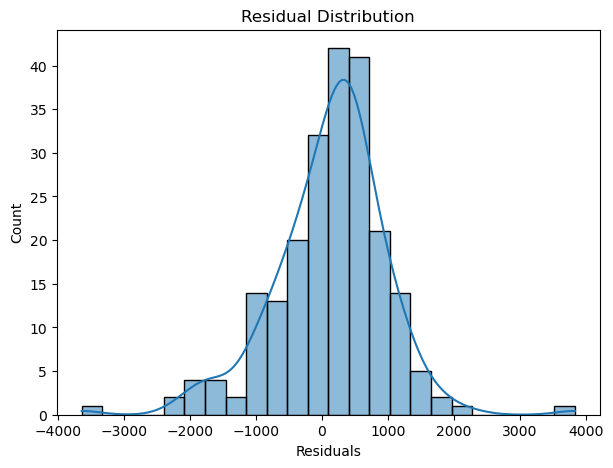

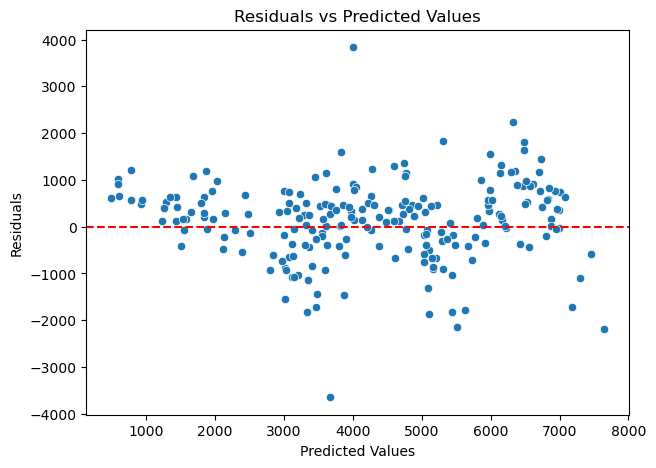

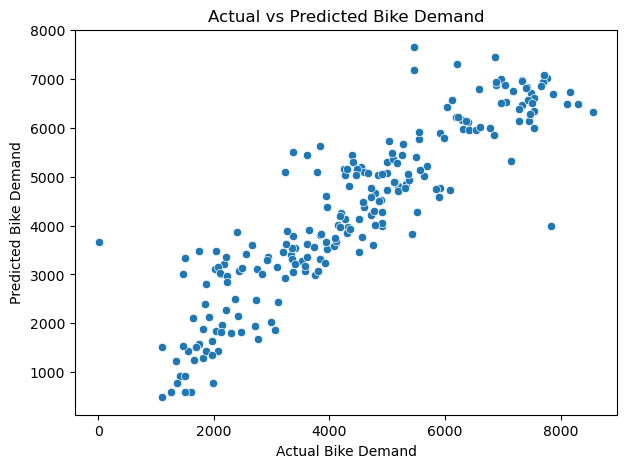

In [13]:
# 11. Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

# 12. Actual vs Predicted
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Bike Demand")
plt.ylabel("Predicted Bike Demand")
plt.title("Actual vs Predicted Bike Demand")
plt.show()